# Chapter 10: Knots and Covering Spaces

**Source orientation:** Armstrong, *Basic Topology*, Chapter 10, printed pp. 213-240; source PDF pages inspected with the course source map at approximately PDF pp. 221-247. The source was used for orientation, terminology, and section order only. The prose, diagrams, examples, and checks below are original to this notebook.

## Chapter Goal

This chapter asks how a closed curve in three-dimensional space can carry information that survives redrawing. A knot diagram is only a projection, so the visible object is not the knot itself. The useful data are the over/under crossing choices, the complement of the knot, the loops in that complement, and the covering spaces that those loops control.

| Book idea | Computational translation | What to inspect |
| --- | --- | --- |
| Tame knots and nice projections | sample a torus-knot curve, project it, and detect transverse self-crossings | crossing count and over/under height gaps |
| Diagram changes | local Reidemeister move atlas | which local feature changes without changing the ambient isotopy class |
| Knot group | Wirtinger generators and relations from a diagram | how crossings become group relations and why the trefoil group is not cyclic |
| Seifert surface | Seifert circles plus twisted bands | Euler characteristic and genus from circle/crossing counts |
| Covering spaces and Alexander polynomial | path lifts, deck transformations, and a Laurent-polynomial presentation matrix | how a covering shift becomes multiplication by `t` |

The visuals are deliberately small. They are models for the mechanisms in the chapter, not replacements for the full theorems. Each artifact is followed by a numerical, symbolic, or structural check.

## Source-Specific Storyboard Implemented

1. **Trefoil projection with crossing data.** A sampled `(2,3)` torus knot is projected from a generic direction. The code detects three double points and records which strand is over by comparing depth.
2. **Reidemeister move atlas.** Three local diagrams explain why projections may change while the ambient knot remains the same.
3. **Wirtinger presentation scaffold.** A proof graph ties trefoil overpasses to crossing relations, and a finite permutation quotient proves the resulting group is not abelian.
4. **Seifert surface bookkeeping.** The Seifert algorithm is represented as circles plus bands; the genus check uses `chi = s - c` and `chi = 2 - 2g - b`.
5. **Covering-space lift and deck-action models.** The circle universal cover shows lifts and integer deck translations. A finite graph cover shows why nonregular covers can have fewer deck transformations than sheets.
6. **Alexander-polynomial intuition.** The trefoil presentation matrix is built over `Z[t,t^-1]`; SymPy computes the determinant and checks the expected symmetry.

In [1]:
from pathlib import Path
import sys, json, math, itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Circle, FancyArrowPatch, PathPatch
from matplotlib.path import Path as MplPath
import networkx as nx
import plotly.graph_objects as go
import sympy as sp
from IPython.display import Markdown, display

def find_book_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
            return candidate
    raise RuntimeError("Could not find Basic-Topology book root")

BOOK_ROOT = find_book_root(Path.cwd())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import artifact_path, save_json, save_plotly_html, assert_artifact, display_artifact

UNIT = "chapter-10"
ARTIFACTS = []
plt.rcParams.update({"figure.dpi": 140, "font.size": 10, "axes.titlesize": 12, "axes.labelsize": 10})

def book_path(path: Path) -> str:
    path = Path(path)
    try:
        return path.relative_to(BOOK_ROOT).as_posix()
    except ValueError:
        return path.as_posix()

def remember(path: Path, concept: str, kind: str, check: str, min_bytes: int = 512) -> Path:
    row = {"path": Path(path), "relative_path": book_path(Path(path)), "concept": concept, "kind": kind, "check": check, "min_bytes": min_bytes}
    ARTIFACTS.append(row)
    return Path(path)

f"Book root: {BOOK_ROOT.name}"

'Book root: Basic-Topology'

## 1. A Trefoil Is Not Its Projection

A projection forgets one coordinate. A nice projection is useful because the forgetting is controlled: only finitely many points collide, and at each collision exactly two strands meet. The code below samples a trefoil as a `(2,3)` torus knot, projects it from a generic direction, and identifies the three double points. The over/under data come from the lost depth coordinate.

**Representation choice.** Plotly carries the spatial curve as a rotatable HTML artifact; Matplotlib gives a durable diagram where crossing gaps and labels stay fixed for later checks.

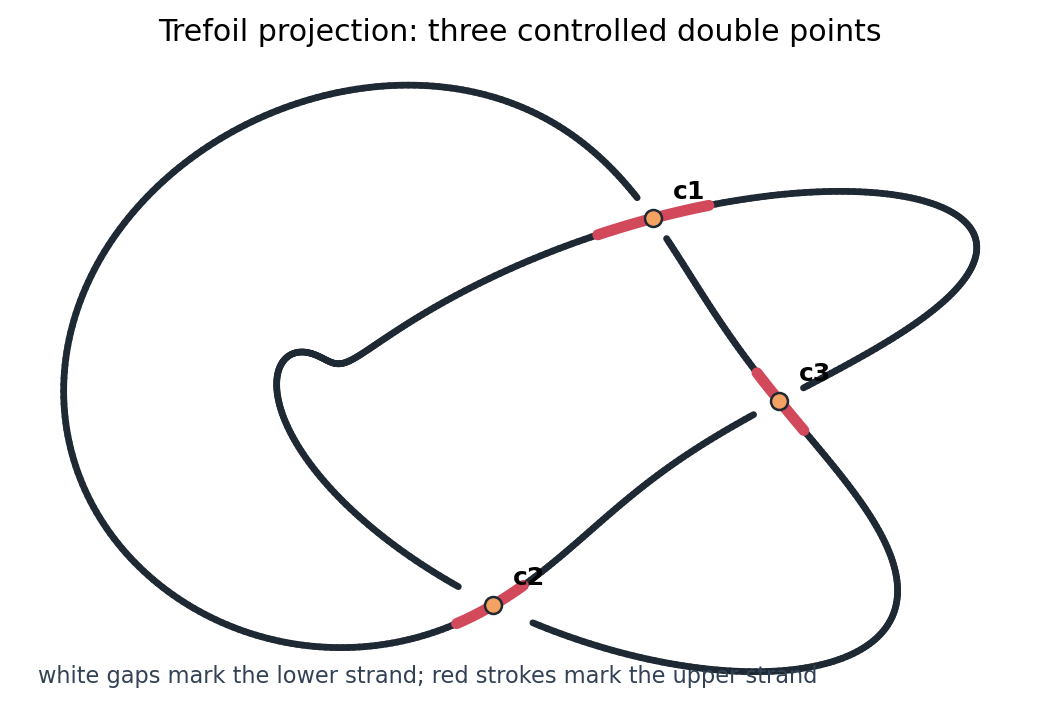

{'concept': 'nice projection for a sampled trefoil',
 'crossing_count': 3,
 'minimum_depth_gap': 1.4469119873546261,
 'maximum_depth_gap': 1.793315082236389,
 'projection_direction': [1, 1, 1],
 'sample_points': 841}

In [2]:
def torus_knot(p=2, q=3, n=840, major=2.0, minor=0.72):
    theta = np.linspace(0, 2 * np.pi, n + 1)
    x = (major + minor * np.cos(q * theta)) * np.cos(p * theta)
    y = (major + minor * np.cos(q * theta)) * np.sin(p * theta)
    z = minor * np.sin(q * theta)
    return theta, np.column_stack([x, y, z])

def projection_basis(view):
    view = np.asarray(view, dtype=float)
    view = view / np.linalg.norm(view)
    anchor = np.array([0.0, 0.0, 1.0]) if abs(np.dot(view, [0, 0, 1])) < 0.9 else np.array([1.0, 0.0, 0.0])
    e1 = np.cross(view, anchor); e1 = e1 / np.linalg.norm(e1)
    e2 = np.cross(view, e1)
    return e1, e2, view

def project_curve(points, view=(1.0, 1.0, 1.0)):
    e1, e2, depth_axis = projection_basis(view)
    return points @ e1, points @ e2, points @ depth_axis

def segment_intersection(a, b, c, d, eps=1e-10):
    r = b - a; s = d - c
    den = r[0] * s[1] - r[1] * s[0]
    if abs(den) < eps:
        return None
    qp = c - a
    u = (qp[0] * s[1] - qp[1] * s[0]) / den
    v = (qp[0] * r[1] - qp[1] * r[0]) / den
    if eps < u < 1 - eps and eps < v < 1 - eps:
        return u, v, a + u * r
    return None

def detect_crossings(u, v, depth, min_index_gap=6):
    n = len(u) - 1
    crossings = []
    for i in range(n):
        a = np.array([u[i], v[i]]); b = np.array([u[i + 1], v[i + 1]])
        for j in range(i + min_index_gap, n):
            if i < min_index_gap and j > n - min_index_gap:
                continue
            hit = segment_intersection(a, b, np.array([u[j], v[j]]), np.array([u[j + 1], v[j + 1]]))
            if hit is None:
                continue
            si, sj, xy = hit
            di = depth[i] + si * (depth[i + 1] - depth[i])
            dj = depth[j] + sj * (depth[j + 1] - depth[j])
            if abs(di - dj) < 1e-3:
                continue
            crossings.append({"segments": (i + si, j + sj), "point": (float(xy[0]), float(xy[1])), "depths": (float(di), float(dj)), "over_segment": float(i + si if di > dj else j + sj), "under_segment": float(j + sj if di > dj else i + si), "height_gap": float(abs(di - dj))})
    return crossings

def circular_distance(a, b, period):
    delta = abs((a - b) % period)
    return min(delta, period - delta)

theta, trefoil_points = torus_knot()
proj_x, proj_y, proj_depth = project_curve(trefoil_points, view=(1, 1, 1))
crossings = detect_crossings(proj_x, proj_y, proj_depth)
assert len(crossings) == 3, crossings

n_segments = len(proj_x) - 1
under_windows = [crossing["under_segment"] for crossing in crossings]
segments = []
for i in range(n_segments):
    midpoint = i + 0.5
    if any(circular_distance(midpoint, under, n_segments) < 5.5 for under in under_windows):
        continue
    segments.append([[proj_x[i], proj_y[i]], [proj_x[i + 1], proj_y[i + 1]]])

fig, ax = plt.subplots(figsize=(7.2, 6.2))
ax.add_collection(LineCollection(segments, colors="#1f2933", linewidths=2.7, capstyle="round"))
for k, crossing in enumerate(crossings, start=1):
    center = int(round(crossing["over_segment"]))
    idx = (np.arange(center - 8, center + 9) % n_segments).astype(int)
    ax.plot(proj_x[idx], proj_y[idx], color="#d1495b", linewidth=4.4, solid_capstyle="round")
    ax.scatter(*crossing["point"], s=46, color="#f4a261", edgecolor="#1f2933", zorder=5)
    ax.annotate(f"c{k}", crossing["point"], xytext=(8, 8), textcoords="offset points", weight="bold")
ax.set_title("Trefoil projection: three controlled double points")
ax.set_aspect("equal"); ax.axis("off")
ax.text(0.02, 0.02, "white gaps mark the lower strand; red strokes mark the upper strand", transform=ax.transAxes, ha="left", va="bottom", fontsize=9, color="#334155")
projection_path = artifact_path(UNIT, "figures", "trefoil-projection-crossing-data.png")
fig.savefig(projection_path, bbox_inches="tight", dpi=180); plt.close(fig)
remember(projection_path, "nice projection and crossing data", "figure", "three transverse crossings with positive depth gaps", min_bytes=2000)

fig3d = go.Figure()
fig3d.add_trace(go.Scatter3d(x=trefoil_points[:, 0], y=trefoil_points[:, 1], z=trefoil_points[:, 2], mode="lines", line=dict(color="#1f77b4", width=6), name="trefoil in space"))
fig3d.add_trace(go.Scatter3d(x=trefoil_points[:, 0], y=trefoil_points[:, 1], z=np.full(len(trefoil_points), -1.05), mode="lines", line=dict(color="rgba(60,60,60,0.28)", width=3), name="shadow projection"))
fig3d.update_layout(title="Trefoil as a (2,3) torus knot", scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="z"), margin=dict(l=0, r=0, t=40, b=0))
html_path = save_plotly_html(fig3d, UNIT, "html", "trefoil-torus-knot-3d.html")
remember(html_path, "spatial knot versus planar shadow", "html", "rotatable curve has a closed sampled path", min_bytes=2000)

crossing_check = {"concept": "nice projection for a sampled trefoil", "crossing_count": len(crossings), "minimum_depth_gap": min(c["height_gap"] for c in crossings), "maximum_depth_gap": max(c["height_gap"] for c in crossings), "projection_direction": [1, 1, 1], "sample_points": int(len(trefoil_points))}
projection_check_path = save_json(crossing_check, UNIT, "checks", "trefoil-projection-crossing-checks.json")
remember(projection_check_path, "projection crossing validation", "check", "crossing count and depth gaps recorded", min_bytes=64)

display_artifact(projection_path, width=760)
display_artifact(html_path, width="100%", height=500)
crossing_check

## 2. Reidemeister Moves As Local Accounting

The chapter works with projections of knots, so the learner needs a way to separate a real topological change from a harmless redraw. Reidemeister moves are the local vocabulary for that separation: a small curl can appear or disappear, a pair of opposite crossings can be created or removed, and one strand can slide past a crossing of two others. The atlas is schematic; its job is to train the eye to ask what changes inside a local disk while the outside diagram is held fixed.

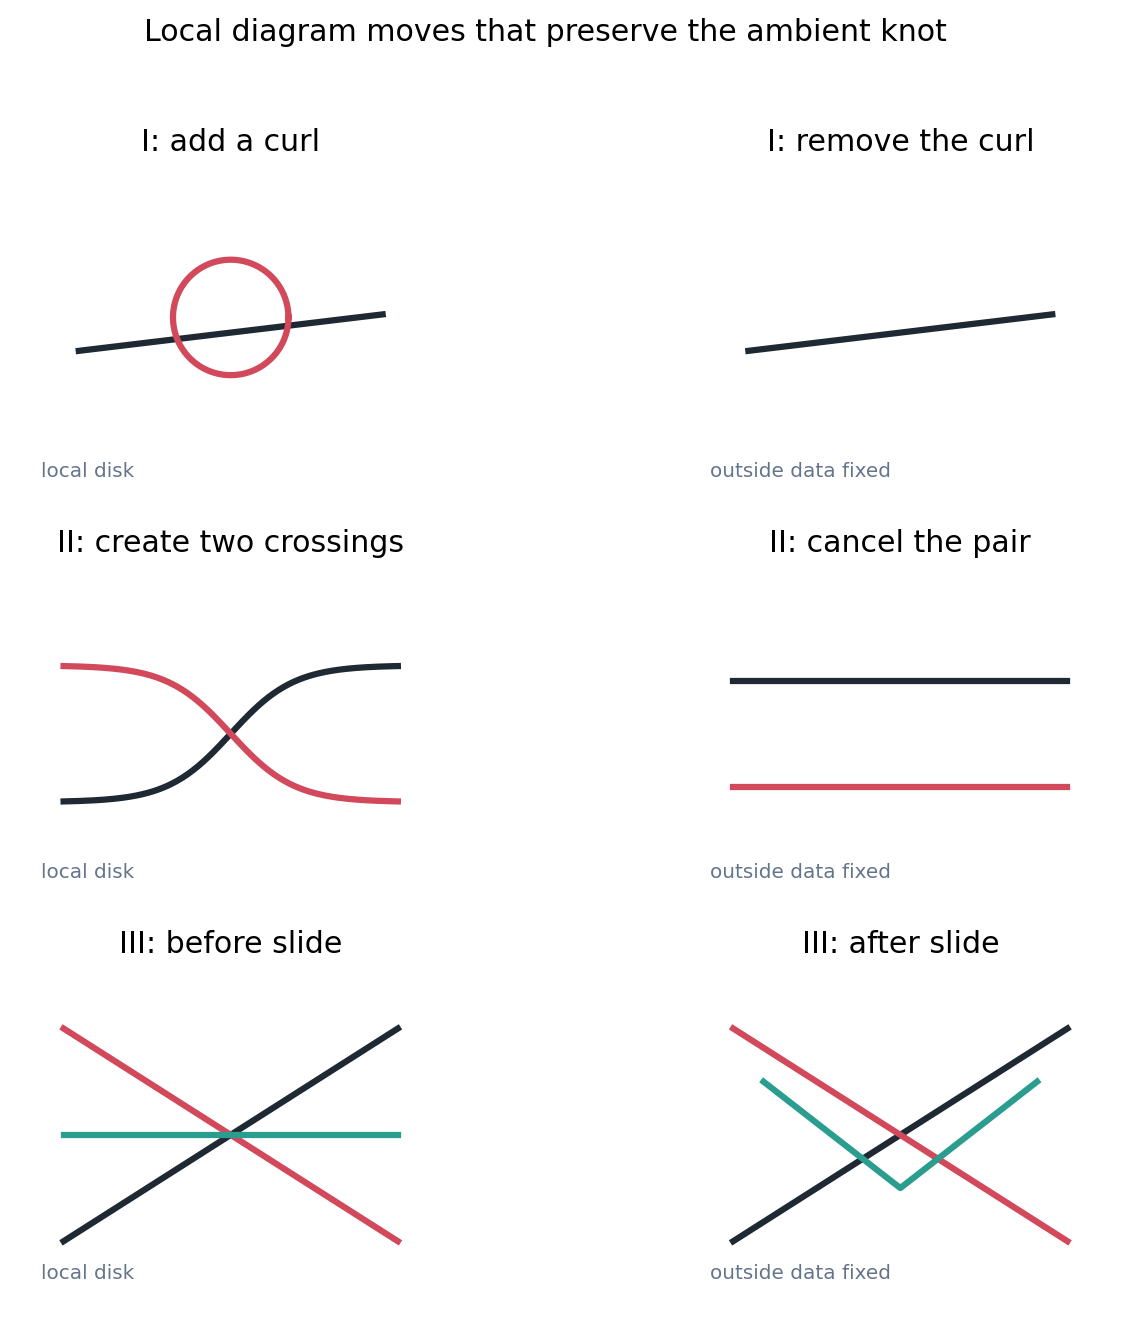

{'concept': 'Reidemeister local move atlas',
 'move_types': ['I', 'II', 'III'],
 'locality_principle': 'outside the small displayed disk, the diagram data are held fixed',
 'artifact': 'artifacts/chapter-10/figures/reidemeister-move-atlas.png'}

In [3]:
def draw_reidemeister_atlas():
    fig, axes = plt.subplots(3, 2, figsize=(8.8, 8.2))
    fig.suptitle("Local diagram moves that preserve the ambient knot", y=0.98)
    for ax in axes.flat:
        ax.set_aspect("equal"); ax.axis("off"); ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.1, 1.1)
    tline = np.linspace(-1, 1, 200)
    axes[0, 0].plot(tline, 0.12 * tline, color="#1f2933", lw=2.5)
    loop_t = np.linspace(0, 2 * np.pi, 180)
    axes[0, 0].plot(0.38 * np.cos(loop_t), 0.38 * np.sin(loop_t) + 0.1, color="#d1495b", lw=2.5)
    axes[0, 0].set_title("I: add a curl")
    axes[0, 1].plot(tline, 0.12 * tline, color="#1f2933", lw=2.5); axes[0, 1].set_title("I: remove the curl")
    x = np.linspace(-1.1, 1.1, 200); y1 = 0.45 * np.tanh(2.4 * x); y2 = -0.45 * np.tanh(2.4 * x)
    axes[1, 0].plot(x, y1, color="#1f2933", lw=2.5); axes[1, 0].plot(x, y2, color="#d1495b", lw=2.5); axes[1, 0].set_title("II: create two crossings")
    axes[1, 1].plot(x, 0.35 + 0 * x, color="#1f2933", lw=2.5); axes[1, 1].plot(x, -0.35 + 0 * x, color="#d1495b", lw=2.5); axes[1, 1].set_title("II: cancel the pair")
    axes[2, 0].plot([-1.1, 1.1], [-0.7, 0.7], color="#1f2933", lw=2.5); axes[2, 0].plot([-1.1, 1.1], [0.7, -0.7], color="#d1495b", lw=2.5); axes[2, 0].plot([-1.1, 1.1], [0.0, 0.0], color="#2a9d8f", lw=2.5); axes[2, 0].set_title("III: before slide")
    axes[2, 1].plot([-1.1, 1.1], [-0.7, 0.7], color="#1f2933", lw=2.5); axes[2, 1].plot([-1.1, 1.1], [0.7, -0.7], color="#d1495b", lw=2.5); axes[2, 1].plot([-0.9, 0.0, 0.9], [0.35, -0.35, 0.35], color="#2a9d8f", lw=2.5); axes[2, 1].set_title("III: after slide")
    for left, right in axes:
        left.text(-1.25, -0.95, "local disk", color="#64748b", fontsize=8)
        right.text(-1.25, -0.95, "outside data fixed", color="#64748b", fontsize=8)
    return fig

fig = draw_reidemeister_atlas()
reidemeister_path = artifact_path(UNIT, "figures", "reidemeister-move-atlas.png")
fig.savefig(reidemeister_path, bbox_inches="tight", dpi=180); plt.close(fig)
remember(reidemeister_path, "Reidemeister move intuition", "figure", "three local move types displayed", min_bytes=2000)
reidemeister_check = {"concept": "Reidemeister local move atlas", "move_types": ["I", "II", "III"], "locality_principle": "outside the small displayed disk, the diagram data are held fixed", "artifact": book_path(reidemeister_path)}
reidemeister_check_path = save_json(reidemeister_check, UNIT, "checks", "reidemeister-move-atlas-checks.json")
remember(reidemeister_check_path, "Reidemeister artifact validation", "check", "records the three move types", min_bytes=64)
display_artifact(reidemeister_path, width=820)
reidemeister_check

## 3. Wirtinger Presentations: Crossings Become Relations

For a nice diagram, every overpass gives a loop in the knot complement. Around a crossing, the incoming underpass generator, outgoing underpass generator, and overpass generator are not independent. Van Kampen's theorem turns that local geometry into a relation.

For the trefoil, a standard reduction gives the group `<a, b | aba = bab>`. The graph below is a scaffold for the proof rather than a picture of the knot. Generator nodes feed relation nodes. A finite quotient check sends `a` and `b` to two transpositions in `S_3`. Since those transpositions satisfy the relation but do not commute, the trefoil group cannot be the infinite cyclic group of the unknot.

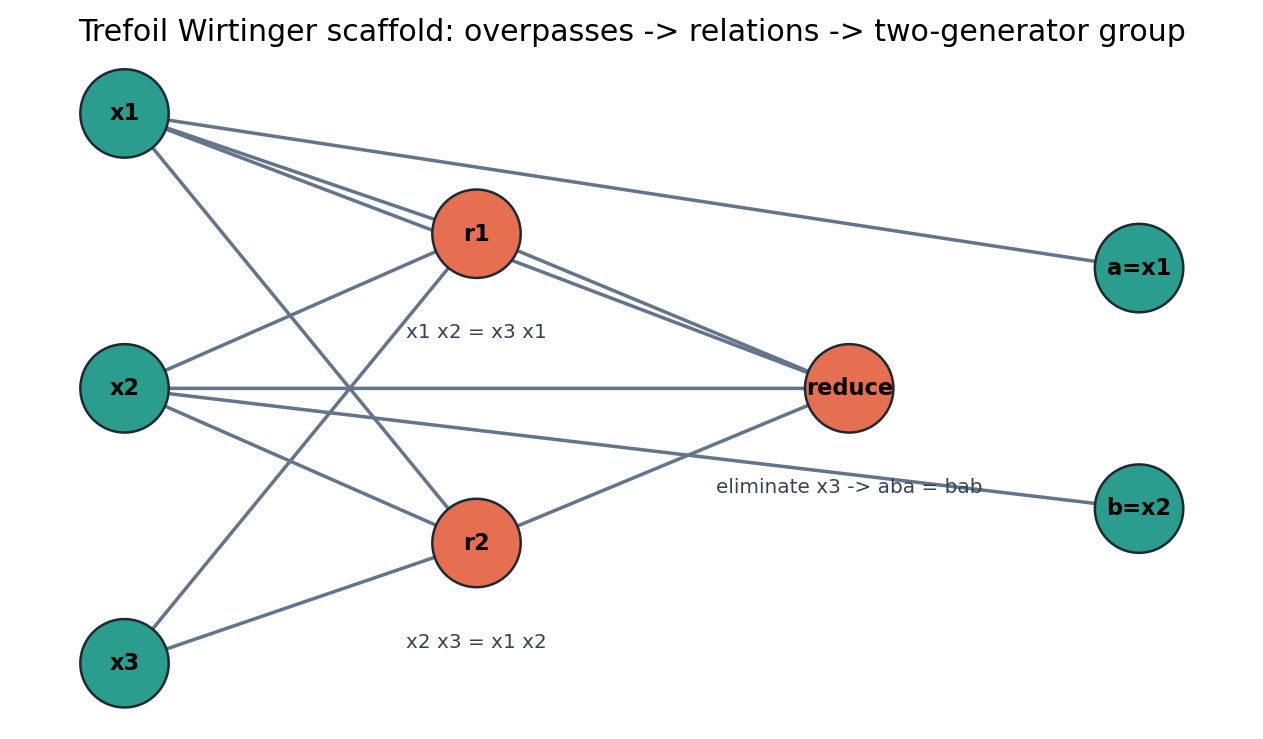

{'concept': 'trefoil knot group has nonabelian finite quotient',
 'presentation': '<a,b | aba=bab>',
 'aba_image': (2, 1, 0),
 'bab_image': (2, 1, 0),
 'relation_holds_in_S3': True,
 'images_commute': False,
 'generated_subgroup_size': 6,
 'abelianization_free_rank': 1}

In [4]:
relations = [("r1", "x1 x2 = x3 x1", ["x1", "x2", "x3"]), ("r2", "x2 x3 = x1 x2", ["x1", "x2", "x3"]), ("reduce", "eliminate x3 -> aba = bab", ["x1", "x2"])]
G = nx.DiGraph()
for generator in ["x1", "x2", "x3", "a=x1", "b=x2"]:
    G.add_node(generator, kind="generator")
for name, label, gens in relations:
    G.add_node(name, kind="relation", label=label)
    for gen in gens:
        G.add_edge(gen, name)
G.add_edge("r1", "reduce"); G.add_edge("r2", "reduce"); G.add_edge("x1", "a=x1"); G.add_edge("x2", "b=x2")
pos = {"x1": (-2.1, 0.8), "x2": (-2.1, 0.0), "x3": (-2.1, -0.8), "r1": (-0.4, 0.45), "r2": (-0.4, -0.45), "reduce": (1.4, 0.0), "a=x1": (2.8, 0.35), "b=x2": (2.8, -0.35)}
colors = ["#2a9d8f" if G.nodes[n]["kind"] == "generator" else "#e76f51" for n in G.nodes]
fig, ax = plt.subplots(figsize=(8.8, 4.8))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=14, width=1.4, edge_color="#64748b")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=1250, edgecolors="#1f2933", linewidths=1.0)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_weight="bold")
for node in ["r1", "r2", "reduce"]:
    x, y = pos[node]
    ax.text(x, y - 0.26, G.nodes[node].get("label", ""), ha="center", va="top", fontsize=8, color="#334155")
ax.set_title("Trefoil Wirtinger scaffold: overpasses -> relations -> two-generator group")
ax.axis("off")
wirtinger_path = artifact_path(UNIT, "figures", "trefoil-wirtinger-presentation-graph.png")
fig.savefig(wirtinger_path, bbox_inches="tight", dpi=180); plt.close(fig)
remember(wirtinger_path, "Wirtinger presentation proof graph", "figure", "relations feed the reduced trefoil presentation", min_bytes=2000)

def compose_perm(p, q):
    return tuple(p[i] for i in q)

def word_perm(word, images):
    result = tuple(range(3))
    for letter in word:
        result = compose_perm(images[letter], result)
    return result

def subgroup_generated(generators, n):
    identity = tuple(range(n)); group = {identity}; changed = True
    while changed:
        changed = False
        for g in list(group):
            for h in generators + list(group):
                for candidate in (compose_perm(g, h), compose_perm(h, g)):
                    if candidate not in group:
                        group.add(candidate); changed = True
    return group

a = (1, 0, 2); b = (0, 2, 1); images = {"a": a, "b": b}
left = word_perm("aba", images); right = word_perm("bab", images); S3_image = subgroup_generated([a, b], 3)
wirtinger_check = {"concept": "trefoil knot group has nonabelian finite quotient", "presentation": "<a,b | aba=bab>", "aba_image": left, "bab_image": right, "relation_holds_in_S3": left == right, "images_commute": compose_perm(a, b) == compose_perm(b, a), "generated_subgroup_size": len(S3_image), "abelianization_free_rank": 1}
assert wirtinger_check["relation_holds_in_S3"]
assert not wirtinger_check["images_commute"]
assert wirtinger_check["generated_subgroup_size"] == 6
wirtinger_check_path = save_json(wirtinger_check, UNIT, "checks", "trefoil-wirtinger-group-checks.json")
remember(wirtinger_check_path, "Wirtinger finite quotient check", "check", "S3 quotient is nonabelian and relation preserving", min_bytes=64)
display_artifact(wirtinger_path, width=860)
wirtinger_check

## 4. Seifert Surfaces: From Crossings To Genus

A Seifert surface spans the knot by an orientable surface whose boundary is the knot. The algorithmic picture is: orient the diagram, smooth every crossing in the orientation-compatible way, span the resulting Seifert circles by disks, then restore the crossings as twisted bands.

For a knot with `s` Seifert circles, `c` crossings, and one boundary component, this surface has `chi = s - c`, and `chi = 2 - 2g - 1`. For the trefoil, `s = 2` and `c = 3`, so `chi = -1` and `g = 1`. This gives a visible orientable surface of genus one.

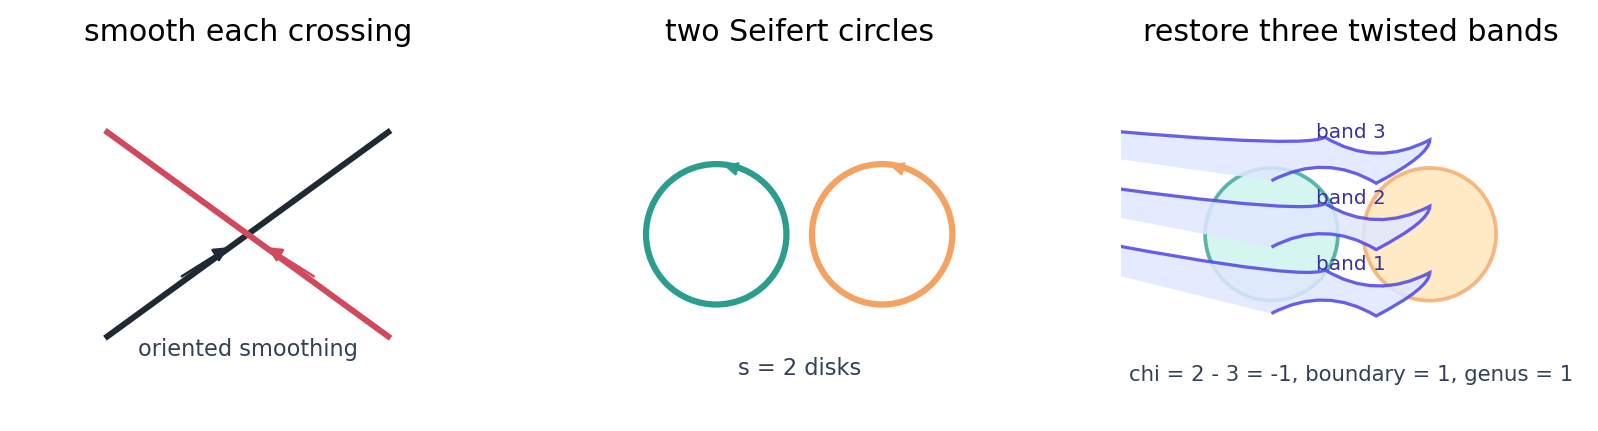

{'concept': 'trefoil Seifert surface bookkeeping',
 'seifert_circles': 2,
 'crossings': 3,
 'boundary_components': 1,
 'euler_characteristic': -1,
 'genus_from_surface': 1,
 'formula': 'chi = s - c = 2 - 2g - b'}

In [5]:
def draw_seifert_model():
    fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.9))
    for ax in axes:
        ax.set_aspect("equal"); ax.axis("off"); ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.4, 1.4)
    axes[0].set_title("smooth each crossing")
    axes[0].plot([-1.1, 1.1], [-0.8, 0.8], color="#1f2933", lw=2.4)
    axes[0].plot([-1.1, 1.1], [0.8, -0.8], color="#d1495b", lw=2.4)
    axes[0].annotate("oriented smoothing", xy=(0.0, -0.95), ha="center", fontsize=9, color="#334155")
    axes[0].add_patch(FancyArrowPatch((-0.55, -0.35), (-0.12, -0.08), arrowstyle="-|>", mutation_scale=12, color="#1f2933"))
    axes[0].add_patch(FancyArrowPatch((0.55, -0.35), (0.12, -0.08), arrowstyle="-|>", mutation_scale=12, color="#d1495b"))
    axes[1].set_title("two Seifert circles")
    for x0, color in [(-0.65, "#2a9d8f"), (0.65, "#f4a261")]:
        axes[1].add_patch(Circle((x0, 0), 0.55, fill=False, lw=2.5, color=color))
        axes[1].add_patch(FancyArrowPatch((x0 + 0.25, 0.49), (x0 + 0.02, 0.55), arrowstyle="-|>", mutation_scale=11, color=color))
    axes[1].text(0, -1.1, "s = 2 disks", ha="center", fontsize=9, color="#334155")
    axes[2].set_title("restore three twisted bands")
    axes[2].add_patch(Circle((-0.62, 0), 0.52, facecolor="#c7f2eb", edgecolor="#2a9d8f", lw=1.5, alpha=0.75))
    axes[2].add_patch(Circle((0.62, 0), 0.52, facecolor="#ffe3b3", edgecolor="#f4a261", lw=1.5, alpha=0.75))
    for idx, y in enumerate([-0.52, 0.0, 0.52], start=1):
        verts = [(-0.62, y - 0.10), (-0.20, y + 0.12), (0.20, y - 0.12), (0.62, y + 0.10), (0.62, y + 0.22), (0.20, y), (-0.20, y + 0.24), (-0.62, y + 0.02), (-0.62, y - 0.10)]
        codes = [MplPath.MOVETO] + [MplPath.CURVE3] * 7 + [MplPath.CLOSEPOLY]
        axes[2].add_patch(PathPatch(MplPath(verts, codes), facecolor="#e0e7ff", edgecolor="#4f46e5", lw=1.3, alpha=0.86))
        axes[2].text(0, y + 0.24, f"band {idx}", ha="center", fontsize=8, color="#3730a3")
    axes[2].text(0, -1.15, "chi = 2 - 3 = -1, boundary = 1, genus = 1", ha="center", fontsize=8.5, color="#334155")
    return fig

fig = draw_seifert_model()
seifert_path = artifact_path(UNIT, "figures", "trefoil-seifert-surface-band-model.png")
fig.savefig(seifert_path, bbox_inches="tight", dpi=180); plt.close(fig)
remember(seifert_path, "Seifert surface from circles and bands", "figure", "Euler characteristic gives genus one", min_bytes=2000)
seifert_circles = 2; crossing_count = 3; boundary_components = 1
euler_characteristic = seifert_circles - crossing_count
genus = int((2 - boundary_components - euler_characteristic) / 2)
seifert_check = {"concept": "trefoil Seifert surface bookkeeping", "seifert_circles": seifert_circles, "crossings": crossing_count, "boundary_components": boundary_components, "euler_characteristic": euler_characteristic, "genus_from_surface": genus, "formula": "chi = s - c = 2 - 2g - b"}
assert euler_characteristic == -1 and genus == 1
seifert_check_path = save_json(seifert_check, UNIT, "checks", "trefoil-seifert-genus-checks.json")
remember(seifert_check_path, "Seifert genus validation", "check", "chi and genus formulas agree", min_bytes=64)
display_artifact(seifert_path, width=900)
seifert_check

## 5. Covering Spaces: Lifts, Sheets, And Deck Transformations

A covering map is locally a product of identical sheets. Globally, a loop in the base may move a lifted path from one sheet to another. That endpoint motion is the computational face of the subgroup of the fundamental group attached to the covering.

The circle cover `R -> S^1` is the clean model: a base loop of winding number one lifts to a path whose endpoint is translated by one integer. The deck transformations are exactly the integer translations. The finite graph model below is a cover of a wedge of two circles encoded by two permutations on four sheets. Its deck transformations are the sheet permutations that commute with both monodromy permutations.

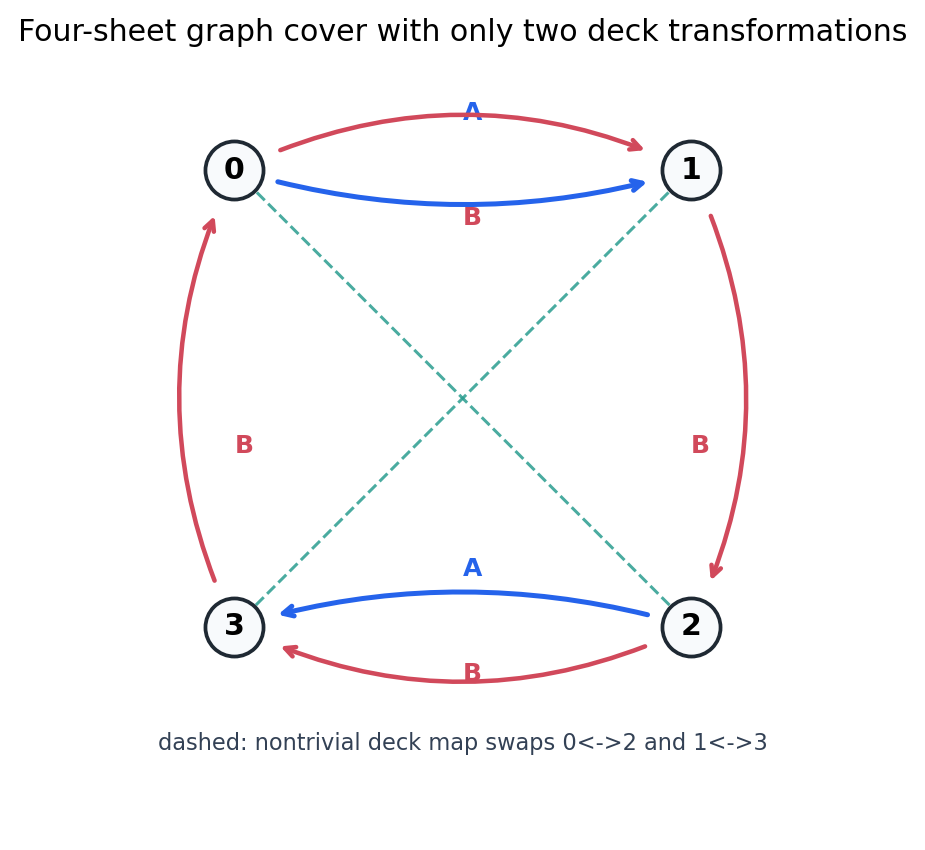

{'concept': 'covering lifts and deck transformations',
 'circle_cover_deck_group': 'Z acting by t -> t+n',
 'graph_cover_sheets': 4,
 'monodromy_A': (1, 0, 3, 2),
 'monodromy_B': (1, 2, 3, 0),
 'fiber_orbit_size': 4,
 'deck_transformation_count': 2,
 'deck_transformations': [(0, 1, 2, 3), (2, 3, 0, 1)],
 'regular_cover_detected': False}

In [6]:
t_vals = np.linspace(-1.0, 2.2, 520)
fig_cover = go.Figure()
fig_cover.add_trace(go.Scatter3d(x=np.cos(2 * np.pi * t_vals), y=np.sin(2 * np.pi * t_vals), z=t_vals, mode="lines", line=dict(color="#2563eb", width=5), name="lifted line over the circle"))
fig_cover.add_trace(go.Scatter3d(x=np.cos(2 * np.pi * t_vals), y=np.sin(2 * np.pi * t_vals), z=np.full_like(t_vals, -1.15), mode="lines", line=dict(color="rgba(31,41,51,0.35)", width=4), name="base circle shadow"))
for start in [-1, 0, 1, 2]:
    fig_cover.add_trace(go.Scatter3d(x=[1], y=[0], z=[start], mode="markers+text", marker=dict(size=5, color="#e76f51"), text=[f"{start}"], textposition="top center", name=f"fiber point {start}", showlegend=False))
fig_cover.update_layout(title="Universal cover of the circle: one base loop shifts the lift by +1", scene=dict(xaxis_title="cos(2 pi t)", yaxis_title="sin(2 pi t)", zaxis_title="lift coordinate t", aspectmode="data"), margin=dict(l=0, r=0, t=44, b=0))
circle_cover_path = save_plotly_html(fig_cover, UNIT, "html", "circle-cover-lifts-and-deck-transformations.html")
remember(circle_cover_path, "circle covering lift and deck translations", "html", "fiber over 1 has integer-indexed points", min_bytes=2000)

A = (1, 0, 3, 2)
B = (1, 2, 3, 0)

def invert_perm(p):
    q = [0] * len(p)
    for i, j in enumerate(p):
        q[j] = i
    return tuple(q)

def centralizer(perms):
    n = len(perms[0]); commuting = []
    for sigma in itertools.permutations(range(n)):
        if all(compose_perm(sigma, p) == compose_perm(p, sigma) for p in perms):
            commuting.append(sigma)
    return commuting

def generated_orbit(perms, start=0):
    gens = list(perms) + [invert_perm(p) for p in perms]
    orbit = {start}; changed = True
    while changed:
        changed = False
        for x in list(orbit):
            for g in gens:
                y = g[x]
                if y not in orbit:
                    orbit.add(y); changed = True
    return orbit

deck_transformations = centralizer([A, B])
orbit0 = generated_orbit([A, B], 0)
assert len(orbit0) == 4 and len(deck_transformations) == 2

pos = {0: (0, 1), 1: (1, 1), 2: (1, 0), 3: (0, 0)}
fig, ax = plt.subplots(figsize=(7.2, 5.6))
for node, (x, y) in pos.items():
    ax.scatter([x], [y], s=540, color="#f8fafc", edgecolor="#1f2933", linewidth=1.5, zorder=3)
    ax.text(x, y, str(node), ha="center", va="center", fontsize=12, weight="bold", zorder=4)
for i, j in enumerate(A):
    if i < j:
        ax.annotate("", xy=pos[j], xytext=pos[i], arrowprops=dict(arrowstyle="->", color="#2563eb", lw=2.0, shrinkA=18, shrinkB=18, connectionstyle="arc3,rad=0.15"))
        ax.text((pos[i][0] + pos[j][0]) / 2, (pos[i][1] + pos[j][1]) / 2 + 0.11, "A", color="#2563eb", weight="bold")
for i, j in enumerate(B):
    ax.annotate("", xy=pos[j], xytext=pos[i], arrowprops=dict(arrowstyle="->", color="#d1495b", lw=1.8, shrinkA=20, shrinkB=20, connectionstyle="arc3,rad=-0.24"))
    ax.text((pos[i][0] + pos[j][0]) / 2, (pos[i][1] + pos[j][1]) / 2 - 0.12, "B", color="#d1495b", weight="bold")
for i, j in enumerate(deck_transformations[1]):
    if i < j:
        ax.plot([pos[i][0], pos[j][0]], [pos[i][1], pos[j][1]], color="#2a9d8f", lw=1.2, ls="--", alpha=0.85)
ax.text(0.5, -0.27, "dashed: nontrivial deck map swaps 0<->2 and 1<->3", ha="center", fontsize=9, color="#334155")
ax.set_title("Four-sheet graph cover with only two deck transformations")
ax.set_aspect("equal"); ax.axis("off"); ax.set_xlim(-0.35, 1.35); ax.set_ylim(-0.45, 1.25)
graph_cover_path = artifact_path(UNIT, "figures", "finite-cover-deck-transformation-model.png")
fig.savefig(graph_cover_path, bbox_inches="tight", dpi=180); plt.close(fig)
remember(graph_cover_path, "finite covering and deck transformation count", "figure", "centralizer size is two while sheet count is four", min_bytes=2000)

covering_check = {"concept": "covering lifts and deck transformations", "circle_cover_deck_group": "Z acting by t -> t+n", "graph_cover_sheets": 4, "monodromy_A": A, "monodromy_B": B, "fiber_orbit_size": len(orbit0), "deck_transformation_count": len(deck_transformations), "deck_transformations": deck_transformations, "regular_cover_detected": len(deck_transformations) == 4}
covering_check_path = save_json(covering_check, UNIT, "checks", "covering-lifts-deck-transformations-checks.json")
remember(covering_check_path, "covering space validation", "check", "transitivity and centralizer/deck count computed", min_bytes=64)
display_artifact(circle_cover_path, width="100%", height=500)
display_artifact(graph_cover_path, width=760)
covering_check

## 6. Alexander Polynomial: The Deck Shift Becomes `t`

The Alexander polynomial packages information from the infinite cyclic cover of the knot complement. Abelianizing the knot group sends every Wirtinger generator to one generator of `Z`; the corresponding regular cover has deck group `Z`; one deck shift acts on first homology, and that action is written as multiplication by `t`. Crossing relations become columns of a matrix over the Laurent polynomial ring `Z[t,t^-1]`.

For the trefoil presentation above, the two-column matrix is `[[1 - t, -1], [t, 1 - t]]`. Its determinant is `t^2 - t + 1`, understood up to multiplication by a unit `+/- t^k`.

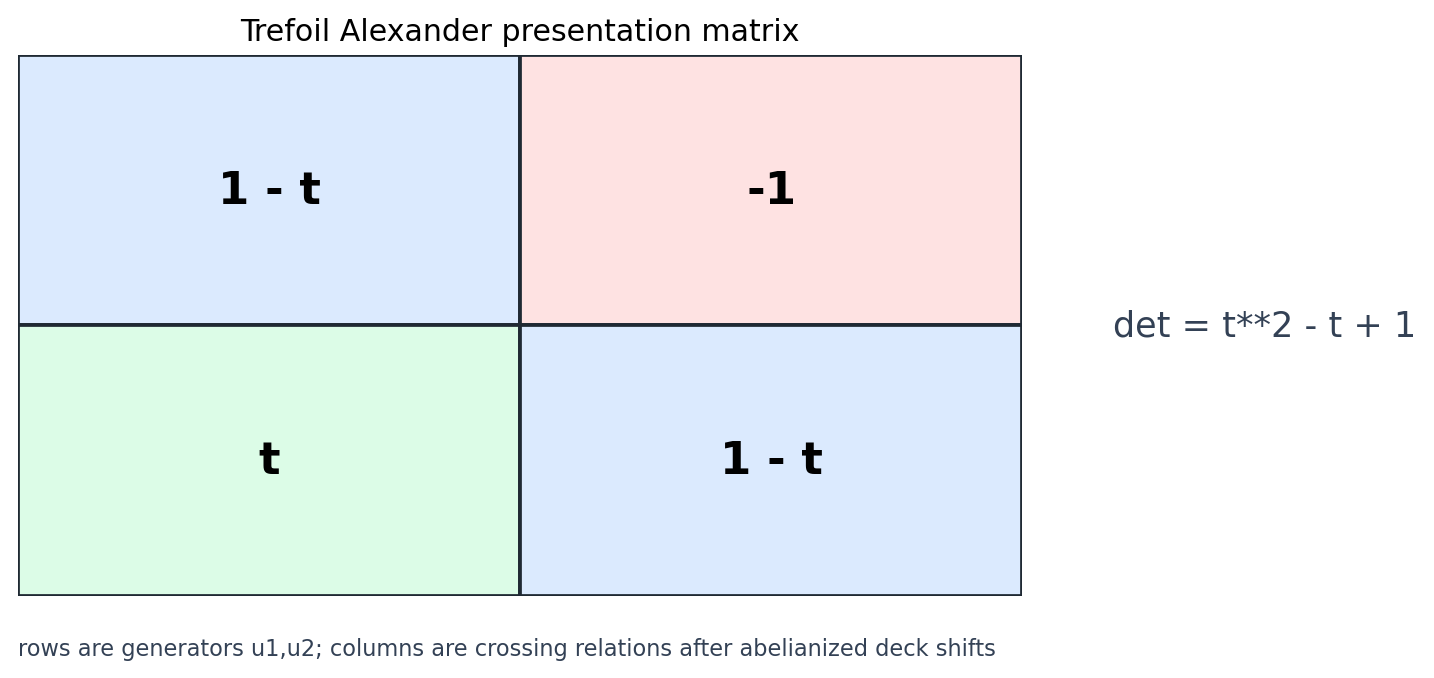

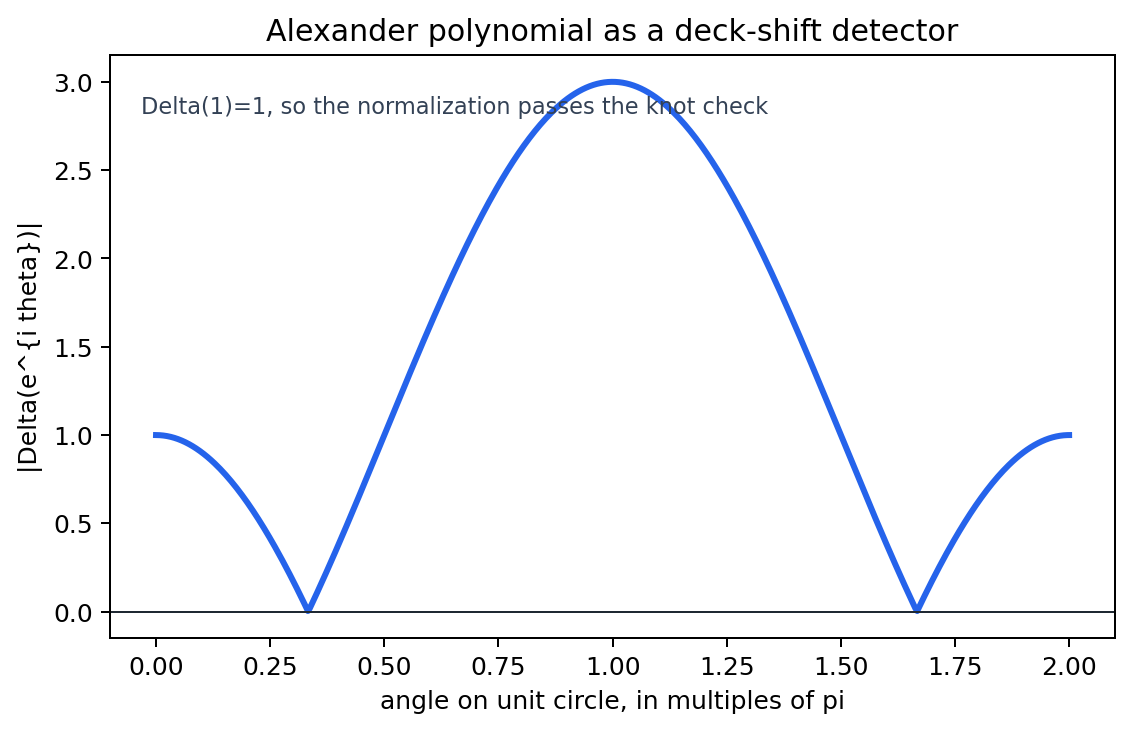

{'concept': 'trefoil Alexander polynomial',
 'matrix': [['1 - t', '-1'], ['t', '1 - t']],
 'determinant': 't**2 - t + 1',
 'delta_at_1': 1,
 'symmetry_residual': '0',
 'unit_ambiguity': '+/- t^k'}

In [7]:
t = sp.symbols("t")
alexander_matrix = sp.Matrix([[1 - t, -1], [t, 1 - t]])
delta_trefoil = sp.expand(alexander_matrix.det())
symmetry_residual = sp.expand(t**2 * delta_trefoil.subs(t, 1 / t) - delta_trefoil)
assert delta_trefoil == t**2 - t + 1
assert symmetry_residual == 0
assert sp.simplify(delta_trefoil.subs(t, 1)) == 1

fig, ax = plt.subplots(figsize=(7.2, 3.9))
ax.set_title("Trefoil Alexander presentation matrix")
ax.set_xlim(0, 2); ax.set_ylim(0, 2); ax.axis("off")
cell_colors = [["#dbeafe", "#fee2e2"], ["#dcfce7", "#dbeafe"]]
entries = [["1 - t", "-1"], ["t", "1 - t"]]
for row in range(2):
    for col in range(2):
        ax.add_patch(plt.Rectangle((col, 1 - row), 1, 1, facecolor=cell_colors[row][col], edgecolor="#1f2933", linewidth=1.5))
        ax.text(col + 0.5, 1.5 - row, entries[row][col], ha="center", va="center", fontsize=18, weight="bold")
ax.text(2.18, 1.0, f"det = {sp.sstr(delta_trefoil)}", va="center", fontsize=14, color="#334155")
ax.text(0.0, -0.22, "rows are generators u1,u2; columns are crossing relations after abelianized deck shifts", fontsize=9, color="#334155")
alexander_matrix_path = artifact_path(UNIT, "figures", "trefoil-alexander-presentation-matrix.png")
fig.savefig(alexander_matrix_path, bbox_inches="tight", dpi=180); plt.close(fig)
remember(alexander_matrix_path, "Alexander polynomial presentation matrix", "figure", "determinant equals t^2 - t + 1", min_bytes=2000)

angles = np.linspace(0, 2 * np.pi, 500); z = np.exp(1j * angles); values = z**2 - z + 1
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(angles / np.pi, np.abs(values), color="#2563eb", lw=2.4)
ax.axhline(0, color="#1f2933", lw=0.8)
ax.set_xlabel("angle on unit circle, in multiples of pi"); ax.set_ylabel("|Delta(e^{i theta})|")
ax.set_title("Alexander polynomial as a deck-shift detector")
ax.text(0.03, 0.90, "Delta(1)=1, so the normalization passes the knot check", transform=ax.transAxes, fontsize=9, color="#334155")
alexander_unit_circle_path = artifact_path(UNIT, "figures", "trefoil-alexander-unit-circle-values.png")
fig.savefig(alexander_unit_circle_path, bbox_inches="tight", dpi=180); plt.close(fig)
remember(alexander_unit_circle_path, "Alexander polynomial values on unit circle", "figure", "Delta(1)=1 and symmetry residual is zero", min_bytes=2000)

alexander_check = {"concept": "trefoil Alexander polynomial", "matrix": [[sp.sstr(entry) for entry in row] for row in alexander_matrix.tolist()], "determinant": sp.sstr(delta_trefoil), "delta_at_1": int(delta_trefoil.subs(t, 1)), "symmetry_residual": sp.sstr(symmetry_residual), "unit_ambiguity": "+/- t^k"}
alexander_check_path = save_json(alexander_check, UNIT, "checks", "trefoil-alexander-polynomial-checks.json")
remember(alexander_check_path, "Alexander symbolic validation", "check", "determinant, normalization, and symmetry checked by SymPy", min_bytes=64)
display_artifact(alexander_matrix_path, width=780)
display_artifact(alexander_unit_circle_path, width=780)
alexander_check

## Applied Lab: Edit A Crossing Column

The Alexander matrix is useful because it turns a diagram into algebra. The small lab below treats the matrix as data. The first row is the trefoil matrix. The second row changes one entry, which should be read as a deliberately broken crossing record rather than a new theorem about knots. The point is to see exactly where the determinant is sensitive.

In [8]:
def polynomial_summary(matrix, name):
    det = sp.expand(sp.Matrix(matrix).det())
    return {"name": name, "determinant": sp.sstr(det), "value_at_t_1": sp.sstr(sp.simplify(det.subs(t, 1))), "symmetric_degree_2_residual": sp.sstr(sp.expand(t**2 * det.subs(t, 1 / t) - det))}

lab_rows = [polynomial_summary(alexander_matrix, "trefoil crossing data"), polynomial_summary(sp.Matrix([[1 - t, -1], [t, 1]]), "edited second diagonal entry")]
lab_df = pd.DataFrame(lab_rows)
lab_path = artifact_path(UNIT, "tables", "alexander-matrix-edit-lab.csv")
lab_df.to_csv(lab_path, index=False)
remember(lab_path, "Alexander matrix editing lab", "table", "determinants and normalization checks compared", min_bytes=32)
lab_df

,name,determinant,value_at_t_1,symmetric_degree_2_residual
0,trefoil crossing data,t**2 - t + 1,1,0
1,edited second diagonal entry,1,1,t**2 - 1


## Final Sanity Checks

The checks below make the notebook accountable. They assert that the major artifacts exist and are nonempty, then check the chapter-specific claims used in the prose: three trefoil projection crossings, a nonabelian finite quotient of the trefoil group, Seifert genus one for the constructed surface, a nonregular four-sheet graph cover with only two deck transformations, and the trefoil Alexander determinant.

In [9]:
sanity_summary = {"source_span": "printed pp. 213-240; PDF pp. approx. 221-247", "projection_crossings": len(crossings), "projection_min_depth_gap": min(c["height_gap"] for c in crossings), "wirtinger_relation_holds_in_S3": wirtinger_check["relation_holds_in_S3"], "wirtinger_nonabelian_images": not wirtinger_check["images_commute"], "seifert_genus": genus, "graph_cover_sheets": covering_check["graph_cover_sheets"], "graph_cover_deck_transformations": covering_check["deck_transformation_count"], "alexander_polynomial": sp.sstr(delta_trefoil), "alexander_delta_at_1": int(delta_trefoil.subs(t, 1)), "alexander_symmetry_residual": sp.sstr(symmetry_residual)}
sanity_path = save_json(sanity_summary, UNIT, "checks", "chapter-10-sanity-checks.json")
remember(sanity_path, "chapter-level sanity checks", "check", "core identities and artifact contract recorded", min_bytes=64)

assert len(crossings) == 3
assert min(c["height_gap"] for c in crossings) > 0.5
assert wirtinger_check["relation_holds_in_S3"]
assert not wirtinger_check["images_commute"]
assert wirtinger_check["generated_subgroup_size"] == 6
assert seifert_check["genus_from_surface"] == 1
assert covering_check["graph_cover_sheets"] == 4
assert covering_check["deck_transformation_count"] == 2
assert not covering_check["regular_cover_detected"]
assert delta_trefoil == t**2 - t + 1
assert int(delta_trefoil.subs(t, 1)) == 1
assert symmetry_residual == 0

seen = set(); artifact_rows = []
for item in ARTIFACTS:
    path = Path(item["path"])
    if path in seen:
        continue
    seen.add(path)
    assert_artifact(path, min_bytes=item["min_bytes"])
    artifact_rows.append({"relative_path": item["relative_path"], "concept": item["concept"], "kind": item["kind"], "size_bytes": path.stat().st_size, "check": item["check"]})
artifact_table = pd.DataFrame(artifact_rows).sort_values(["kind", "relative_path"]).reset_index(drop=True)
artifact_table

,relative_path,concept,kind,size_bytes,check
0,artifacts/chapter-10/checks/chapter-10-sanity-...,chapter-level sanity checks,check,438,core identities and artifact contract recorded
1,artifacts/chapter-10/checks/covering-lifts-dec...,covering space validation,check,495,transitivity and centralizer/deck count computed
2,artifacts/chapter-10/checks/reidemeister-move-...,Reidemeister artifact validation,check,276,records the three move types
3,artifacts/chapter-10/checks/trefoil-alexander-...,Alexander symbolic validation,check,269,"determinant, normalization, and symmetry check..."
4,artifacts/chapter-10/checks/trefoil-projection...,projection crossing validation,check,252,crossing count and depth gaps recorded
5,artifacts/chapter-10/checks/trefoil-seifert-ge...,Seifert genus validation,check,230,chi and genus formulas agree
6,artifacts/chapter-10/checks/trefoil-wirtinger-...,Wirtinger finite quotient check,check,330,S3 quotient is nonabelian and relation preserving
7,artifacts/chapter-10/figures/finite-cover-deck...,finite covering and deck transformation count,figure,63175,centralizer size is two while sheet count is four
8,artifacts/chapter-10/figures/reidemeister-move...,Reidemeister move intuition,figure,76036,three local move types displayed
9,artifacts/chapter-10/figures/trefoil-alexander...,Alexander polynomial presentation matrix,figure,32560,determinant equals t^2 - t + 1


## Takeaways

- A nice knot projection is a controlled loss of information: the missing depth coordinate is exactly what tells us over from under.
- The knot group is a complement invariant, and Wirtinger relations make it computable from a diagram. For the trefoil, a nonabelian `S_3` quotient already separates it from the unknot.
- Seifert's construction gives an orientable spanning surface from diagram data; for the trefoil model here, the surface has genus one.
- Covering spaces turn loops into endpoint motion on sheets. Regularity is visible in whether deck transformations can move freely across each fiber.
- The Alexander polynomial records the action of the infinite cyclic deck shift on first homology; in the trefoil case the determinant is `t^2 - t + 1`.